SAMAGRA GUPTA 590014891 EXPERIMENT 3

In [1]:
import numpy as np                   
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})


In [4]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df = df.astype(float)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000.0,7420.0,4.0,2.0,3.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0
1,12250000.0,8960.0,4.0,4.0,4.0,1.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0
2,12250000.0,9960.0,3.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,0.0
3,12215000.0,7500.0,4.0,2.0,2.0,1.0,0.0,1.0,0.0,1.0,3.0,1.0,0.0,0.0
4,11410000.0,7420.0,4.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0


In [ ]:
X = df.drop("price", axis=1).values
y = df["price"].values.reshape(-1, 1)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [8]:
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0)

y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

In [9]:
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

In [10]:
def compute_loss(X, y, beta):
    predictions = X @ beta
    loss = np.mean((y - predictions) ** 2)
    return loss

In [11]:
def adam_optimizer(X, y,
                   lr=0.5,
                   epochs=500,
                   beta1=0.9,
                   beta2=0.999,
                   epsilon=1e-8,
                   bias_correction=True):

    m, n = X.shape
    beta = np.zeros((n, 1))

    v = np.zeros((n, 1))
    s = np.zeros((n, 1))

    loss_history = []

    for t in range(1, epochs + 1):

        predictions = X @ beta
        gradient = (-2/m) * X.T @ (y - predictions)

        v = beta1 * v + (1 - beta1) * gradient
        s = beta2 * s + (1 - beta2) * (gradient ** 2)

        if bias_correction:
            v_corrected = v / (1 - beta1**t)
            s_corrected = s / (1 - beta2**t)
        else:
            v_corrected = v
            s_corrected = s

        beta = beta - lr * v_corrected / (np.sqrt(s_corrected) + epsilon)

        loss = compute_loss(X, y, beta)
        loss_history.append(loss)

    return beta, loss_history


In [12]:
beta_adam_corrected, loss_corrected = adam_optimizer(
    X_train, y_train,
    beta1=0.9,
    beta2=0.999,
    bias_correction=True
)

beta_adam_uncorrected, loss_uncorrected = adam_optimizer(
    X_train, y_train,
    beta1=0.9,
    beta2=0.999,
    bias_correction=False
)

beta_adam_lowbeta, loss_lowbeta = adam_optimizer(
    X_train, y_train,
    beta1=0.2,
    beta2=0.2,
    bias_correction=True
)


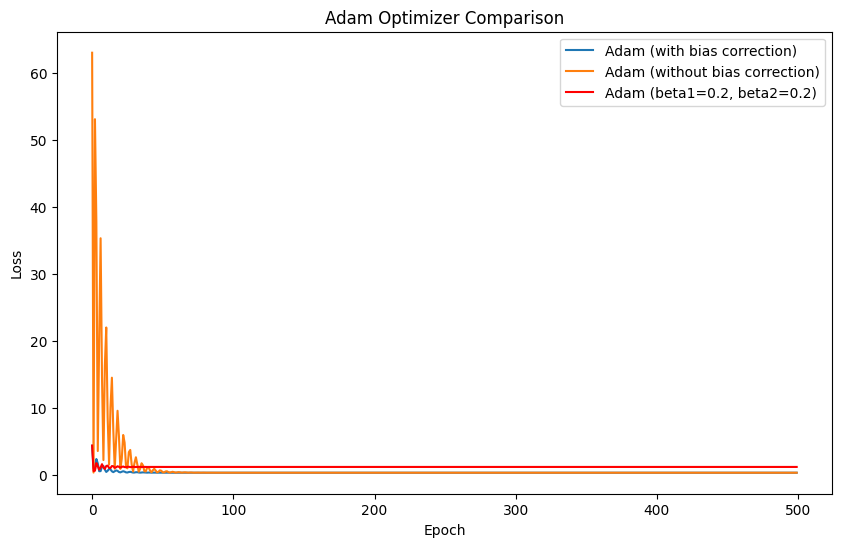

In [13]:
plt.figure(figsize=(10,6))

plt.plot(loss_corrected, label="Adam (with bias correction)")
plt.plot(loss_uncorrected, label="Adam (without bias correction)")
plt.plot(loss_lowbeta, label="Adam (beta1=0.2, beta2=0.2)", color='red')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam Optimizer Comparison")
plt.legend()

plt.show()


In [14]:
y_pred = X_test @ beta_adam_corrected


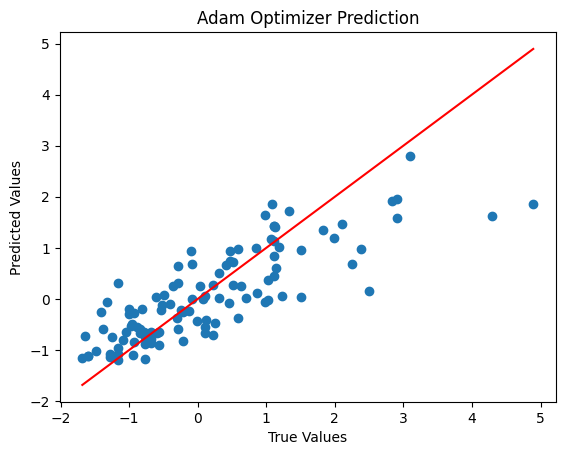

In [15]:
plt.figure()

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Adam Optimizer Prediction")

plt.show()
